## Sales & Customer Analytics using Python

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sto=pd.read_csv(r"F:\jupyter\Projects\sales data\stores.csv")
sal=pd.read_csv(r"F:\jupyter\Projects\sales data\sales.csv")
cust=pd.read_csv(r"F:\jupyter\Projects\sales data\customers.csv")
cal=pd.read_csv(r"F:\jupyter\Projects\sales data\calendar.csv")
prod=pd.read_csv(r"F:\jupyter\Projects\sales data\products.csv")

In [34]:
sto.columns

Index(['store_id', 'store_name', 'city', 'country', 'store_type'], dtype='str')

In [35]:
cust.columns

Index(['customer_id', 'age', 'gender', 'loyalty_member', 'join_date'], dtype='str')

In [36]:
cal.columns

Index(['date', 'year', 'month', 'day', 'week', 'day_of_week'], dtype='str')

In [37]:
prod.columns

Index(['product_id', 'product_name', 'brand', 'category', 'cocoa_percent',
       'weight_g'],
      dtype='str')

In [38]:
sal.columns

Index(['order_id', 'order_date', 'product_id', 'store_id', 'customer_id',
       'quantity', 'unit_price', 'discount', 'revenue', 'cost', 'profit'],
      dtype='str')

## Merging of all the table into one table from diffrent csv files

In [39]:
df=sal.merge(cust,on="customer_id",how="left")

In [40]:
df=df.merge(prod,on="product_id",how="left")

In [41]:
df=df.merge(cal,left_on="order_date",right_on="date",how="left")

In [42]:
df=df.merge(sto,on="store_id",how="left")

In [43]:
df.head()

,order_id,order_date,product_id,store_id,customer_id,quantity,unit_price,discount,revenue,cost,...,date,year,month,day,week,day_of_week,store_name,city,country,store_type
0,0RD00000001,2023-01-07,P0080,S093,C040749,5,14.43,0.15,61.33,42.77,...,2023-01-07,2023,1,7,1,5,Chocolate Store 93,Sydney,UK,Airport
1,0RD00000002,2023-10-22,P0173,S065,C020161,3,12.01,0.00,36.03,19.06,...,2023-10-22,2023,10,22,42,6,Chocolate Store 65,New York,Australia,Retail
2,0RD00000003,2023-05-07,P0115,S078,C048069,2,10.02,0.00,20.04,10.29,...,2023-05-07,2023,5,7,18,6,Chocolate Store 78,London,UK,Airport
3,0RD00000004,2024-06-23,P0186,S088,C047901,2,14.66,0.10,26.39,16.35,...,2024-06-23,2024,6,23,25,6,Chocolate Store 88,Toronto,USA,Retail
4,0RD00000005,2024-09-24,P0197,S054,C033950,1,12.34,0.00,12.34,7.94,...,2024-09-24,2024,9,24,39,1,Chocolate Store 54,London,Canada,Online


In [44]:
df.shape

(1000000, 30)

In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000000 entries, 0 to 999999
Data columns (total 30 columns):
 #   Column          Non-Null Count    Dtype  
---  ------          --------------    -----  
 0   order_id        1000000 non-null  str    
 1   order_date      1000000 non-null  str    
 2   product_id      1000000 non-null  str    
 3   store_id        1000000 non-null  str    
 4   customer_id     1000000 non-null  str    
 5   quantity        1000000 non-null  int64  
 6   unit_price      1000000 non-null  float64
 7   discount        1000000 non-null  float64
 8   revenue         1000000 non-null  float64
 9   cost            1000000 non-null  float64
 10  profit          1000000 non-null  float64
 11  age             1000000 non-null  int64  
 12  gender          1000000 non-null  str    
 13  loyalty_member  1000000 non-null  int64  
 14  join_date       1000000 non-null  str    
 15  product_name    990236 non-null   str    
 16  brand           990236 non-null   str    
 17  c

In [46]:
df.describe()

,quantity,unit_price,discount,revenue,cost,profit,age,loyalty_member,cocoa_percent,weight_g,year,month,day,week,day_of_week
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,1000000.000000,990236.000000,990236.000000,1000000.00000,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,2.999589,9.002449,0.056248,25.486129,15.291554,10.194565,44.044222,0.501898,69.148132,107.431400,2023.50043,6.516521,15.726768,26.444866,2.999049
std,1.413621,3.462902,0.076809,16.367864,9.972706,6.778760,15.330664,0.499997,14.597137,50.719617,0.50000,3.449879,8.806623,15.069053,2.003559
min,1.000000,3.000000,0.000000,2.400000,1.200000,0.730000,18.000000,0.000000,50.000000,50.000000,2023.00000,1.000000,1.000000,1.000000,0.000000
25%,2.000000,6.000000,0.000000,12.160000,7.240000,4.780000,31.000000,0.000000,50.000000,80.000000,2023.00000,4.000000,8.000000,13.000000,1.000000
50%,3.000000,9.010000,0.000000,21.920000,13.030000,8.600000,44.000000,1.000000,70.000000,100.000000,2024.00000,7.000000,16.000000,26.000000,3.000000
75%,4.000000,12.000000,0.150000,35.880000,21.410000,14.170000,57.000000,1.000000,80.000000,120.000000,2024.00000,10.000000,23.000000,39.000000,5.000000
max,5.000000,15.000000,0.200000,75.000000,52.430000,37.430000,70.000000,1.000000,90.000000,200.000000,2024.00000,12.000000,31.000000,52.000000,6.000000


## Data Cleaning

In [47]:
df.isnull().sum()

order_id             0
order_date           0
product_id           0
store_id             0
customer_id          0
quantity             0
unit_price           0
discount             0
revenue              0
cost                 0
profit               0
age                  0
gender               0
loyalty_member       0
join_date            0
product_name      9764
brand             9764
category          9764
cocoa_percent     9764
weight_g          9764
date                 0
year                 0
month                0
day                  0
week                 0
day_of_week          0
store_name           0
city                 0
country              0
store_type           0
dtype: int64

In [48]:
sal["product_id"].nunique()
prod["product_id"].nunique()

200

In [49]:
df = df.dropna(subset=["product_name"])

In [50]:
df.isnull().sum()

order_id          0
order_date        0
product_id        0
store_id          0
customer_id       0
quantity          0
unit_price        0
discount          0
revenue           0
cost              0
profit            0
age               0
gender            0
loyalty_member    0
join_date         0
product_name      0
brand             0
category          0
cocoa_percent     0
weight_g          0
date              0
year              0
month             0
day               0
week              0
day_of_week       0
store_name        0
city              0
country           0
store_type        0
dtype: int64

In [51]:
df.head()
df.info()


<class 'pandas.DataFrame'>
Index: 990236 entries, 0 to 999999
Data columns (total 30 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   order_id        990236 non-null  str    
 1   order_date      990236 non-null  str    
 2   product_id      990236 non-null  str    
 3   store_id        990236 non-null  str    
 4   customer_id     990236 non-null  str    
 5   quantity        990236 non-null  int64  
 6   unit_price      990236 non-null  float64
 7   discount        990236 non-null  float64
 8   revenue         990236 non-null  float64
 9   cost            990236 non-null  float64
 10  profit          990236 non-null  float64
 11  age             990236 non-null  int64  
 12  gender          990236 non-null  str    
 13  loyalty_member  990236 non-null  int64  
 14  join_date       990236 non-null  str    
 15  product_name    990236 non-null  str    
 16  brand           990236 non-null  str    
 17  category        990236 non

In [52]:
df["revenue"].sum().astype(int)

np.int64(25238648)

In [53]:
df["revenue"].mean()

np.float64(25.487508250558452)

## Data Organizing

In [54]:
# Top 10 products by revenue

top_products=df.groupby("product_name")["revenue"].sum().sort_values(ascending=False).head(10)
top_products = top_products / 1000000
top_products

product_name
Dark Chocolate 50%       1.775041
Truffle Chocolate 80%    1.643259
Milk Chocolate 70%       1.384758
Praline Chocolate 50%    1.382597
Dark Chocolate 60%       1.272650
White Chocolate 50%      1.265950
White Chocolate 90%      1.137969
White Chocolate 80%      1.133285
Truffle Chocolate 90%    1.132884
Praline Chocolate 70%    1.127405
Name: revenue, dtype: float64

In [55]:
#Monthly Trend by Sales

monthly_sales=df.groupby("month")["revenue"].sum().astype(int)
monthly_sales=monthly_sales/1000000
monthly_sales

month
1     2.157534
2     1.960211
3     2.147152
4     2.061387
5     2.141643
6     2.064064
7     2.148545
8     2.149425
9     2.087740
10    2.126795
11    2.057294
12    2.136852
Name: revenue, dtype: float64

## Data Visualization (EDA)

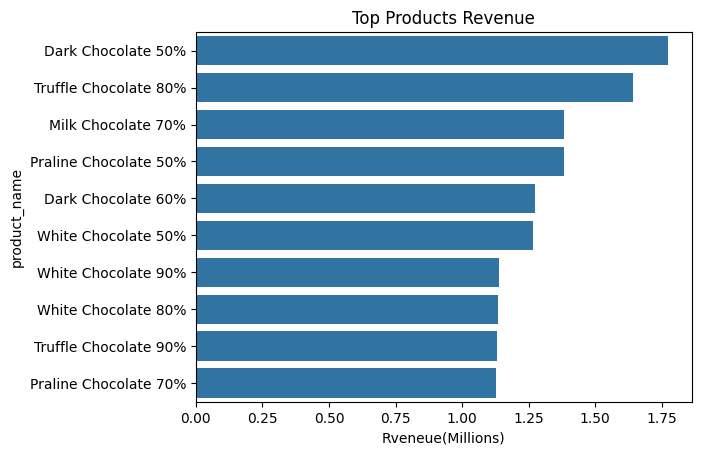

In [56]:
sns.barplot(x=top_products.values,y=top_products.index)
plt.title("Top Products Revenue")
plt.xlabel("Rveneue(Millions)")
plt.show()

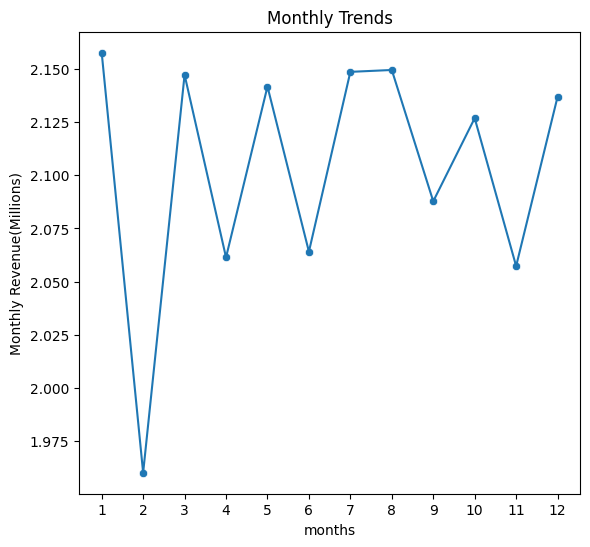

In [57]:
plt.figure(figsize=(22,6))
plt.subplot(131)
sns.lineplot(x=monthly_sales.index,y=monthly_sales.values)
plt.title("Monthly Trends")
plt.subplot(131)
sns.scatterplot(x=monthly_sales.index,y=monthly_sales.values)
plt.xlabel("months")
plt.ylabel("Monthly Revenue(Millions)")
plt.xticks(range(1,13))
plt.show()

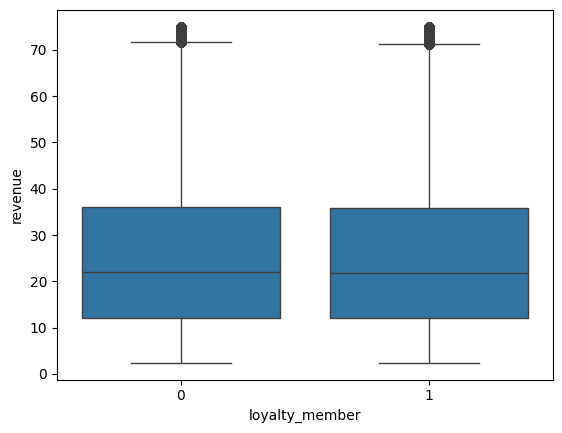

In [58]:
#Loyalty Members vs Their Revenue Contributions
sns.boxplot(x="loyalty_member", y="revenue", data=df)
plt.show()

In [59]:
category_profit=df.groupby("category")["profit"].sum()
category_profit

category
Dark       2120672.08
Milk       1312407.13
Praline    2665242.79
Truffle    1569202.54
White      2428117.37
Name: profit, dtype: float64

In [60]:
corr = df.corr(numeric_only=True)

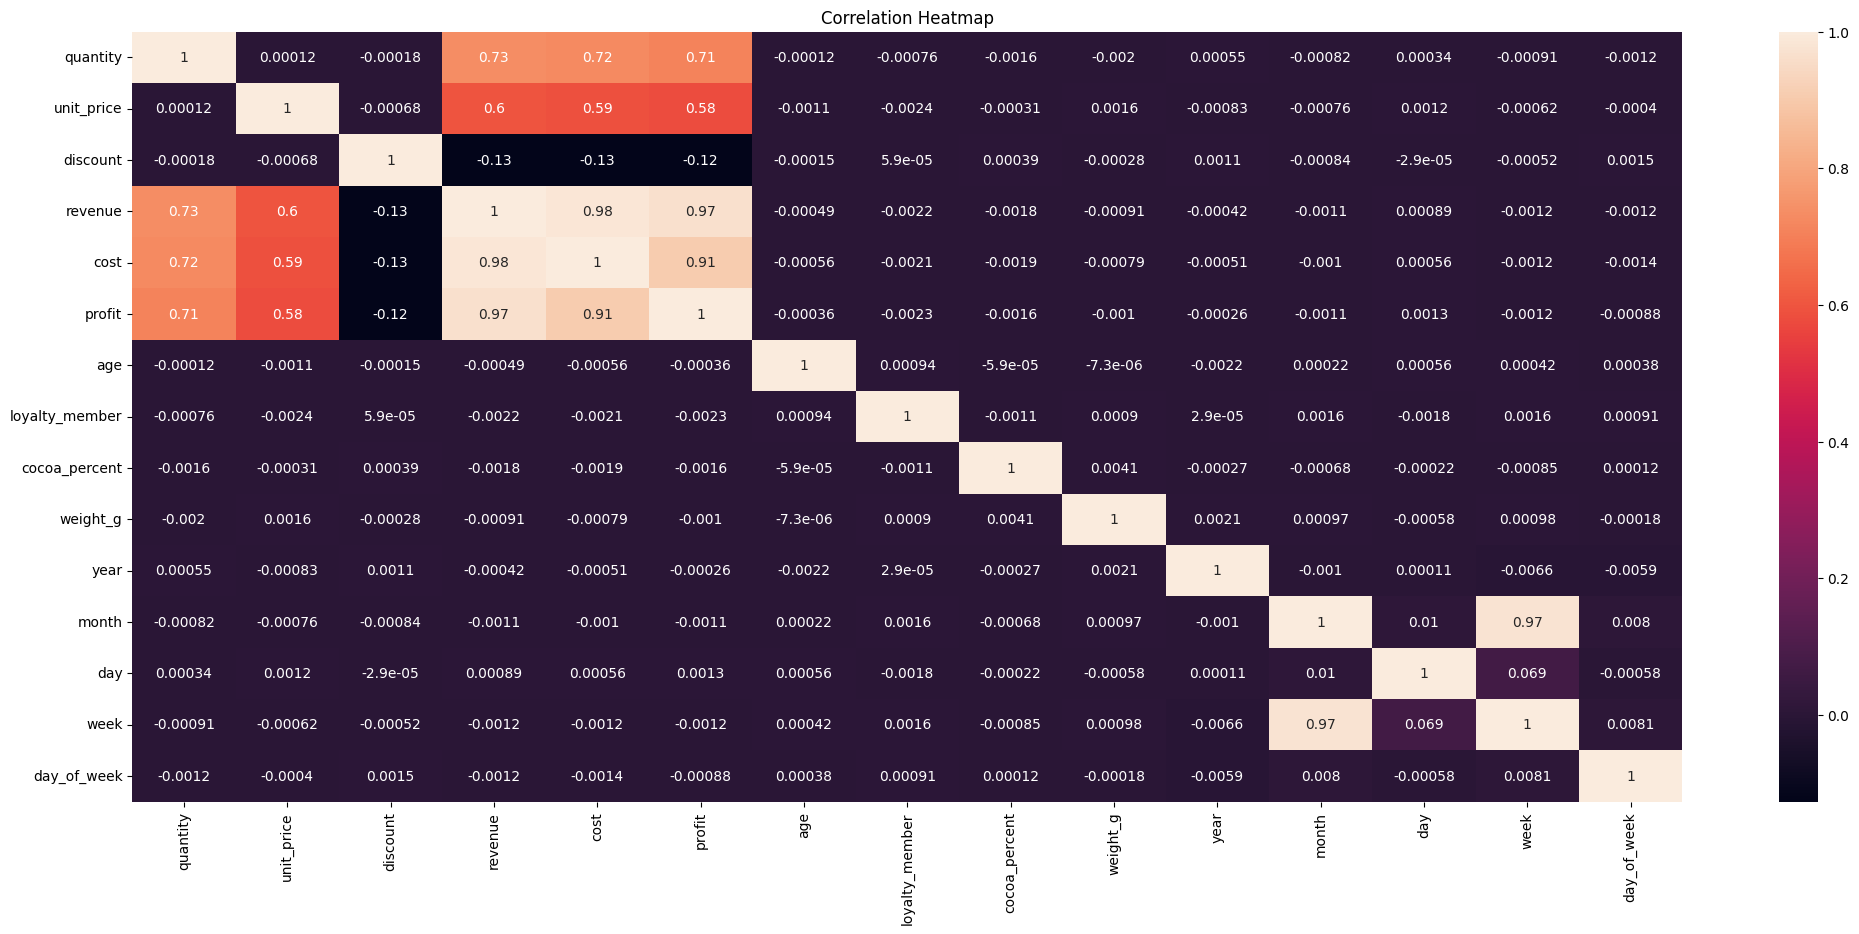

In [61]:
plt.figure(figsize=(25,10))
sns.heatmap(corr, annot=True)
plt.title("Correlation Heatmap")
plt.show()

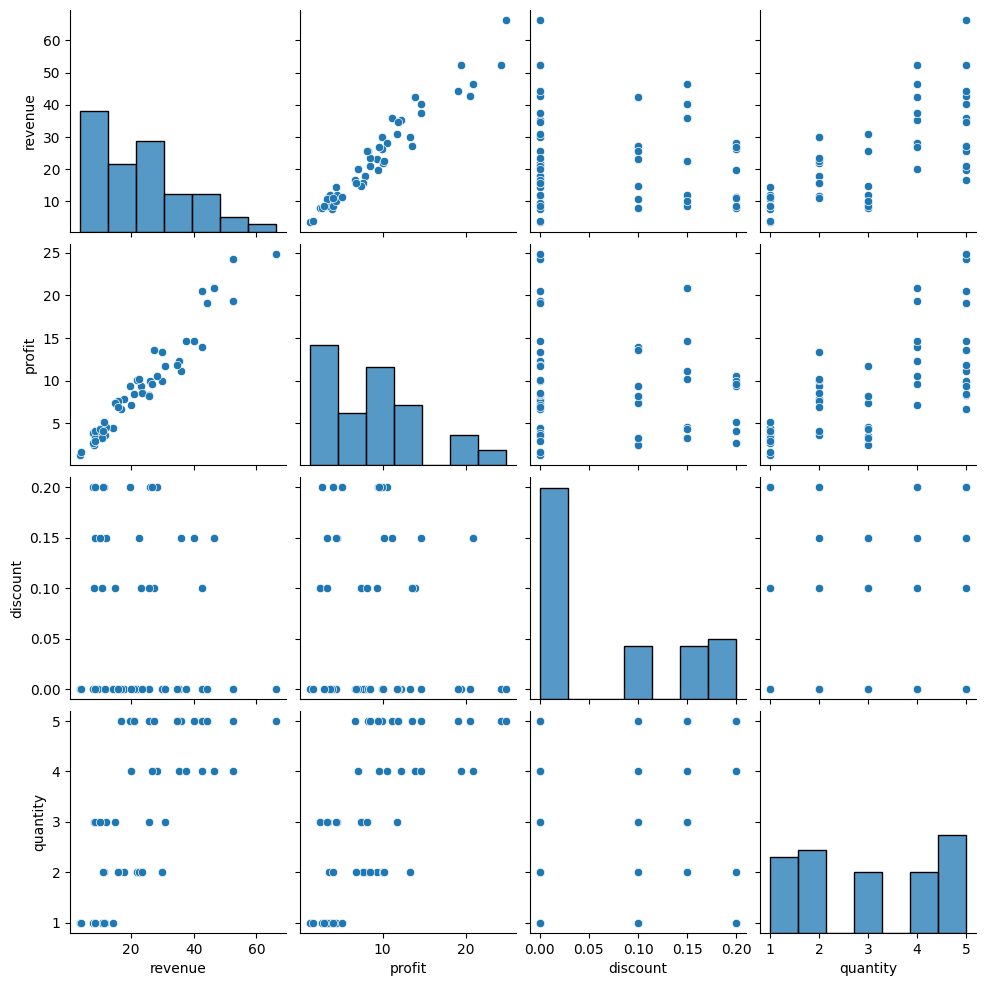

In [62]:
sample_df = df[["revenue", "profit", "discount", "quantity"]].dropna()
sns.pairplot(sample_df.sample(50))
plt.show()

## Business Insights from my analysis:

1. Top-selling products contribute a major share of total revenue.

2. Revenue trends indicate seasonal fluctuations across months.

3. Loyalty members spend more on average than non-loyalty customers.

4. Higher discounts negatively impact profitability.

5. Certain product categories generate higher profit margins.